<a href="https://colab.research.google.com/github/AM0ya/Clase_Programacion/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_269712.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Alfredo Moya Orozco
- **Matrícula:** 269712

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [10]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.

print('Media:  ', df['price'].mean())
print('Mediana:', df['price'].median())
print('Moda:   ', df['price'].mode())

#seccion para analizar mas los valores obtenidos
print('\nDivergencia Media vs Mediana:', df['price'].mean() - df['price'].median())
print("Analisis de la columna:")
df['price'].describe()


Media:   152.7206871868289
Mediana: 106.0
Moda:    0    100
Name: price, dtype: int64

Divergencia Media vs Mediana: 46.72068718682891
Analisis de la columna:


,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_ La diferencia entre media y mediana tienen una diferencia de 46.72.  por lo que representan una divergencia "no tan alarmante" entre si considerando que la moda es 100. Revisando el valor maximo que es 10,000. Se podria deducir que la poblacion de los datos se encuentra sesgada a la derecha(Asimetria positiva), considerando el valor maximo como un outlier.

---
## Actividad 2 — Dispersión (20 pts)

In [18]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.

#Calculo de Rango
maximo=df['price'].max()
minimo=df['price'].min()
rango=maximo-minimo
print(f'Rango:{rango}')

#Calculo de Varianza
varianza=df['price'].var()
print(f'Varianza:{varianza:,.2f}')

#Calculo de Desviacion Estandar
std=df['price'].std()
print(f'Desviacion Estandar:{std:,.2f}')

#Caldulo de IQR
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
print(f'Q1:{Q1:,.2f}')
print(f'Q3:{Q3:,.2f}')
print(f'IQR:{IQR:,.2f}')



Rango:10000
Varianza:57,674.03
Desviacion Estandar:240.15
Q1:69.00
Q3:175.00
IQR:106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ Al realizar la comparacion de el "Rango VS IQR". El mas representativo resulta ser el IQR, ya que el 50% de nuestros datos se concentran dentro de una dispersion mas típica de los precios. Esto es devido a que el valor maximo (10,000) representa un outlier como lo vimos en la respuesta de la seccion anterior. Esto nos da mas claridad de que el valor maximo es realmente un valor atipico y no se encuentra dentro del IQR (no lo mueve).

---
## Actividad 3 — Forma (20 pts)

In [20]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
print('Asimetría de price (con outlier):   ', df['price'].skew())
print('Asimetría de price (sin outlier):   ', df[df['price'] != 10000]['price'].skew())
print('Curtosis de price (con outlier):   ', df['price'].kurt())
print('Curtosis de price (sin outlier):   ', df[df['price'] != 10000]['price'].kurt())



Asimetría de price (con outlier):    19.118938995046033
Asimetría de price (sin outlier):    17.537796724130484
Curtosis de price (con outlier):    585.6728788988286
Curtosis de price (sin outlier):    513.3790135058739


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_Para este analisis primero hice la comparacion con y sin outlier. Se obtuvo un resultado muy similar para ambos casos. Para Skew tenemos una Asimetria positiva (la distribucion se inclina hacia la derecha), y el valor elevado en Kurt nos indica colas extremadamente pesadas (lejanas a 0 fuera de una distribucion normal).
Entendiendo estos datos y comparandolos con el ejercicio anterior y enfocandonos solo a los resultados con Outlier incluido, se nota que la asimetria y la curtosis son mas extremas (Aproximadamente el triple para ambos). Podemos concluir que una gran poblacion de los datos de "price" se encuentran enfocados en valores bajos debido a una Asimetria Extrema positiva y una Hipercurtosis. La relacion esperada con estos valores es que si la Asimetria es positiva, y la Curtosis es elevada, tienen una relacion directa a donde se encuentra la mayoria de los datos.
Estos datos nos hablan de que existe una clara evidencia de datos con valores atipicos

---
## Actividad 4 — Visualización (30 pts)

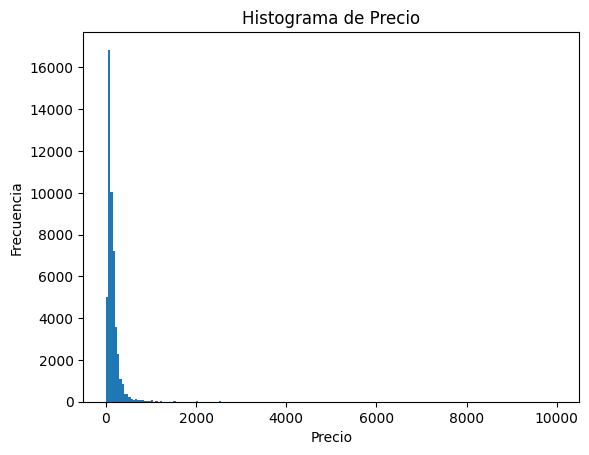

In [35]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
df['price'].plot(kind='hist', bins=200)
plt.title('Histograma de Precio')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

#Se eligio el numero 200 para bins porque durante el analisis previo se detecto que la mayoria de los datos
#se encuentran en valores bajos. Realice distintas visualizaciones para ver la distribucion y el numero 200 representaba menor ruido visual
#en la grafica. Al agregar mas valor a "bin" el histograma de distorcionaba un poco. Por lo que 200 represento un histograma mas suavizado para la
#interpretacion visual.


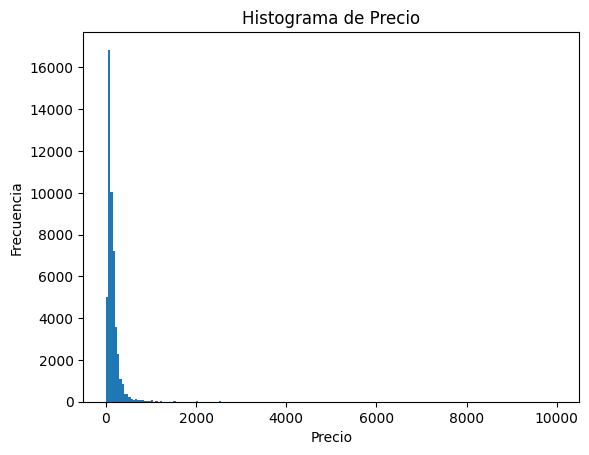

In [36]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.hist(df['price'], bins=200)
plt.title('Histograma de Precio')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()




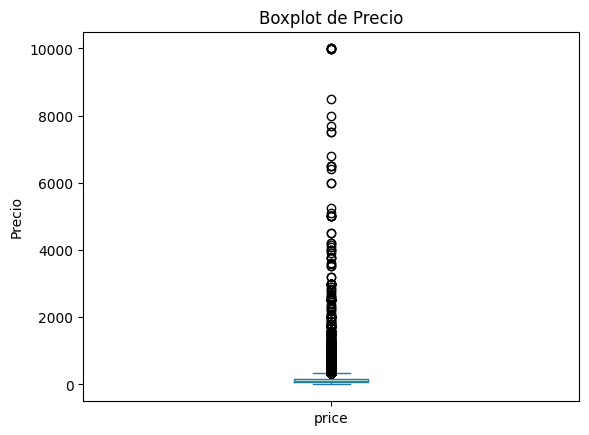

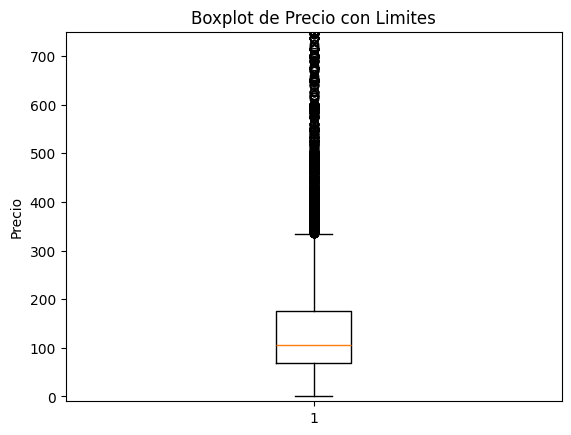

In [46]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
df['price'].plot(kind='box')
plt.title('Boxplot de Precio')
plt.ylabel('Precio')
plt.show()


#para una mejor visualizacion agregue un limite excluyendo los valores atipicos y mostrar de forma mas coherente el boxplot.
#esto sirve solo como comparacion grafica de visualizacion sin limites vs con limites utilizando ambos metodos para graficar boxplot.
plt.boxplot(df['price'])
plt.title('Boxplot de Precio con Limites')
plt.ylabel('Precio')
plt.ylim(-10, 750)
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_El en analisis del Histograma se puede observar una clara concentracion de datos en valores bajos, con una clara asimetria positiva. Y en el Boxplot podemos ver claramente la distribucion de los outliers y donde se encuentra el 50% de los valores (Mayoria Tipica) y la representacion de la elevada curtosis. Esto nos confirma la relacion directa de concentracion de los datos y densida de las colas (la distribución se aleja de la normalidad al presentar colas leptocúrticas). La visibilidad es mas evidente en el grafico de Boxplot ya que muestra la gran cantidad de valores atipicos fuera de la poblacion del 50% (IQR).

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_El promedio del precio (price) de este conjunto de datos del dataset no es confiable o resulta engañoso, ya que existe una gran cantidad de datos que se alejan de este valor promedio. Es necesario hacer un analisis mas profundo. Por ejemplo, al momento de conocer el valor maximo de los datos nos da 10,000.
Profundizando para encontrar la distribucion correcta de los datos podemos ver que realmente existen outliers muy elevados, asi mismo la Curtosis (585.67) y la Asimetria (19.11) nos dan valores muy elevados (positivamente), lo que es un fiel indicador de que existen muchos valores alejados del promedio.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |